This notebook creates the figures for my thesis about the experiments when u is governed by a neural ODE.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

In [2]:
no_t_preds = np.load("../results/no_t_final_preds.npy")
no_t_currents = np.load("../results/no_t_final_additional_currents.npy")
no_t_losses = np.load("../results/no_t_losses.npy")
with_t_preds = np.load("../results/with_t_final_preds.npy")
with_t_currents = np.load("../results/with_t_final_additional_currents.npy")
with_t_losses = np.load("../results/with_t_losses.npy")
no_t_interrupted_preds = np.load("../results/no_t_interrupted_final_preds.npy")
no_t_interrupted_currents = np.load("../results/no_t_interrupted_final_additional_currents.npy")
no_t_interrupted_losses = np.load("../results/no_t_interrupted_losses.npy")

v_multi = np.load("../results/v_multi.npy")
v_single = np.load("../results/no_nn_final_preds.npy")

time_vec = np.arange(0, 200+2*0.025, 0.025)

In [3]:
epochs = np.arange(1000)[::10]

# Make sure the losses are numpy arrays
no_t_losses = np.asarray(no_t_losses)[::10] 
with_t_losses = np.asarray(with_t_losses)[::10] 
no_t_interrupted_losses = np.asarray(no_t_interrupted_losses)[::10] 

# Split curves at epoch 500
epoch_500_idx = np.where(epochs == 500)[0][0]

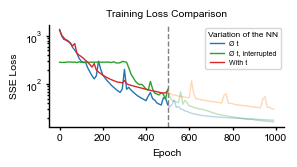

In [ ]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, ax = plt.subplots(figsize=(3, 1.7))

    # Plot with transparency after epoch 200
    ax.plot(epochs[:epoch_500_idx + 1], no_t_losses[:epoch_500_idx + 1], label="Ø t", color='C0')
    ax.plot(epochs[epoch_500_idx:], no_t_losses[epoch_500_idx:], color='C0', alpha=0.3)
    
    ax.plot(epochs[:epoch_500_idx + 1], no_t_interrupted_losses[:epoch_500_idx + 1], label="Ø t, interrupted", color='C2')
    ax.plot(epochs[epoch_500_idx:], no_t_interrupted_losses[epoch_500_idx:], color='C2', alpha=0.3)

    ax.plot(epochs[:epoch_500_idx + 1], with_t_losses[:epoch_500_idx + 1], label="With t", color='C3')
    ax.plot(epochs[epoch_500_idx:], with_t_losses[epoch_500_idx:], color='C1', alpha=0.3)


    # Vertical line at epoch 200
    ax.axvline(500, linestyle='--', color='gray', linewidth=1)
    ax.set_yscale("log")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("SSE Loss")
    ax.set_title("Training Loss Comparison")
    ax.legend(title="Variation of the NN", frameon = True, fontsize = 5, title_fontsize = 6)

    fig.savefig("../svg/losses_comparison.svg", bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()

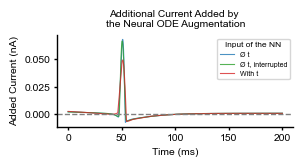

In [ ]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, ax = plt.subplots(figsize=(3, 1.7))

    # Plot each current trace
    ax.plot(time_vec, no_t_currents * 1/300.0, label="Ø t", color='C0', linewidth=0.8, alpha = 0.8)
    ax.plot(time_vec, no_t_interrupted_currents * 1/150.0, label="Ø t, interrupted", color='C2', linewidth=0.8, alpha = 0.8)
    ax.plot(time_vec, with_t_currents * 1/20.0, label="With t", color='C3', linewidth=0.8, alpha = 0.8)
    

    # Add horizontal line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Added Current (nA)")
    ax.set_title("Additional Current Added by \nthe Neural ODE Augmentation")
    ax.legend(title="Input of the NN", frameon = True, fontsize = 5, title_fontsize = 6)

    fig.savefig("../svg/additional_currents.svg", bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()

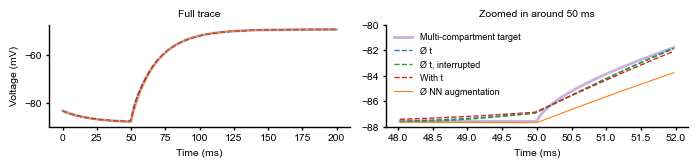

In [ ]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1, 2, figsize=(7, 1.7), sharey=False)

    # Plot 1: Full trace
    axs[0].plot(time_vec, v_multi[0], label="Multi-compartment target", linewidth=2, color = 'C4', alpha = 0.5)
    axs[0].plot(time_vec, no_t_preds, label="v, u", linestyle="--", linewidth=1, color='C0')
    axs[0].plot(time_vec, no_t_interrupted_preds, label="t", linestyle="--", linewidth=1, color='C2')
    axs[0].plot(time_vec, with_t_preds, label="v, u, t", linestyle="--", linewidth=1, color='C3')
    axs[0].plot(time_vec, v_single[0], label="no NN", linestyle="-", linewidth=0.5, color='C1')
    axs[0].set_xlabel("Time (ms)")
    axs[0].set_ylabel("Voltage (mV)")
    axs[0].set_title("Full trace")

    # Plot 2: Zoomed around t=50 ms
    zoom_center = 50
    window = 2  # zoom window ±2 ms
    mask = (time_vec > (zoom_center - window)) & (time_vec < (zoom_center + window))

    axs[1].plot(time_vec[mask], v_multi[0][mask], label="Multi-compartment target", linewidth=2, color = 'C4', alpha = 0.5)
    axs[1].plot(time_vec[mask], no_t_preds[mask], label="Ø t", linestyle="--", linewidth=1, color='C0')
    axs[1].plot(time_vec[mask], no_t_interrupted_preds[mask], label="Ø t, interrupted", linestyle="--", linewidth=1, color='C2')
    axs[1].plot(time_vec[mask], with_t_preds[mask], label="With t", linestyle="--", linewidth=1, color='C3')
    axs[1].plot(time_vec[mask], v_single[0][mask], label="Ø NN augmentation", linestyle="-", linewidth=0.8, color='C1')
    axs[1].set_xlabel("Time (ms)")
    axs[1].set_ylim(-88, -80)
    axs[1].set_title(f"Zoomed in around {zoom_center} ms")
    axs[1].legend(fontsize = 6.5)

    fig.savefig("../svg/predictions_comparison.svg", bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()

In [10]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("14.7cm", "9.8cm",
           
    Panel(
          SVG("../svg/losses_comparison.svg").scale(svg_scale),
          Text("a", 10, 2.0, **kwargs_text),
    ).move(10, 10),
    
    Panel(
          SVG("../svg/additional_currents.svg").scale(svg_scale),
          Text("b", 0, 12.0, **kwargs_text),
    ).move(280, 0),

    Panel(
          SVG("../svg/predictions_comparison.svg").scale(svg_scale),
          Text("c", 10, 10.0, **kwargs_text),
    ).move(10, 192),


)

#!mkdir -p fig
f.save("../fig/u_diff.svg")
svg("../fig/u_diff.svg")